# Week 2 - Data Preprocessing and Feature Engineering

## Breast Cancer Diagnostic Classification

This notebook demonstrates the data understanding, quality analysis,
data splitting, scaling, and preprocessing strategy used for the
Breast Cancer Diagnostic Classification project.

The dataset contains 569 samples and 30 numerical features.


## 1. Import Required Libraries

The following libraries are used:

- NumPy - numerical operations
- Pandas - data analysis
- Matplotlib - visualization
- Seaborn - statistical visualization
- Scikit-learn - dataset loading and preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")
print("Seaborn version:", sns.__version__)


Libraries imported successfully.
Seaborn version: 0.13.2


## 2. Load the Dataset

The Breast Cancer Wisconsin Diagnostic dataset available through
scikit-learn is used for this project.


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully.")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Dataset loaded successfully.
Feature matrix shape: (569, 30)
Target shape: (569,)


## 3. Understand the Dataset

In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature names:")
print(list(X.columns))

print("\nTarget distribution:")
print(y.value_counts())


Number of samples: 569
Number of features: 30

Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


## 4. Data Quality Analysis

The following checks identify missing values, duplicate rows,
and basic statistical characteristics.


In [4]:
print("Missing values:")
print(X.isnull().sum().sum())

print("\nDuplicate rows:")
print(X.duplicated().sum())

print("\nDescriptive statistics:")
display(X.describe())


Missing values:
0

Duplicate rows:
0

Descriptive statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 5. Target Distribution Visualization

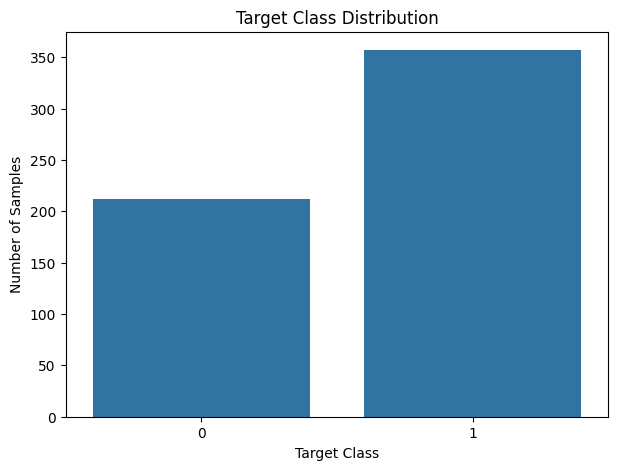

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.show()


## 6. Feature Distribution

A sample of important numerical features is visualized to understand
their distributions.


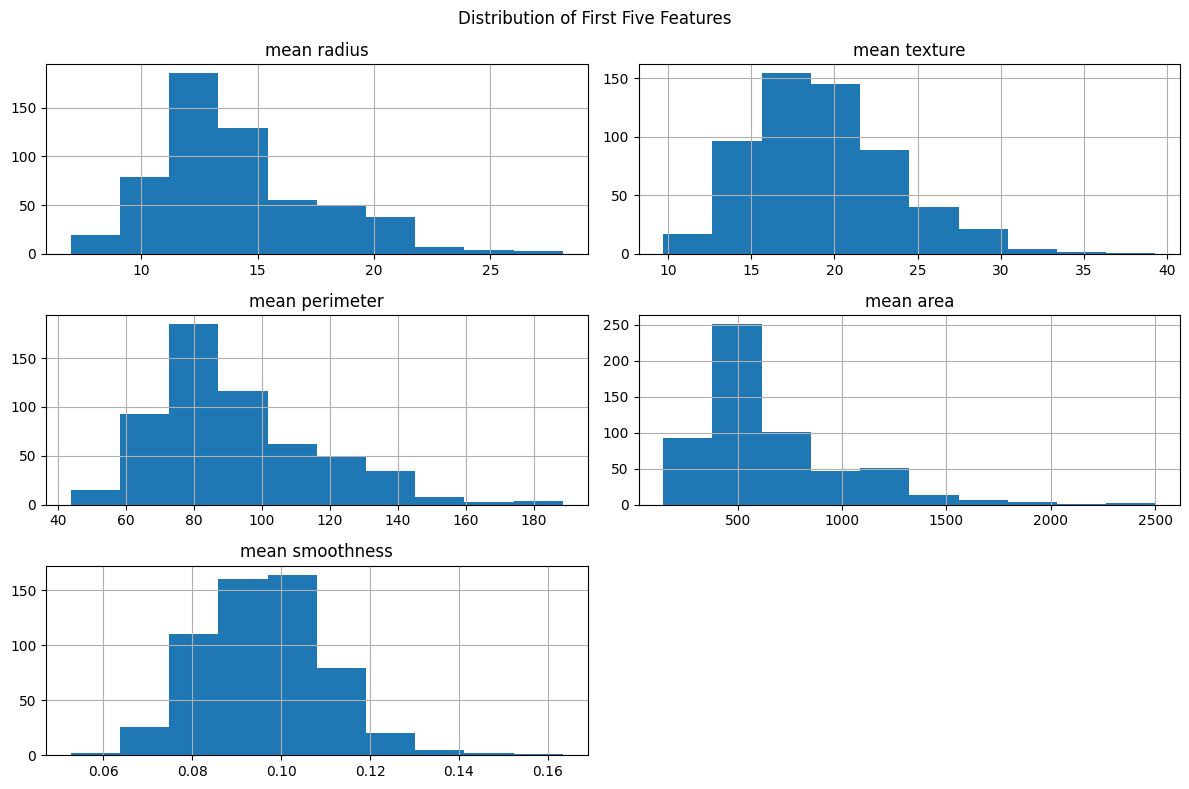

In [6]:
X.iloc[:, :5].hist(figsize=(12, 8))
plt.suptitle("Distribution of First Five Features")
plt.tight_layout()
plt.show()


## 7. Correlation Analysis

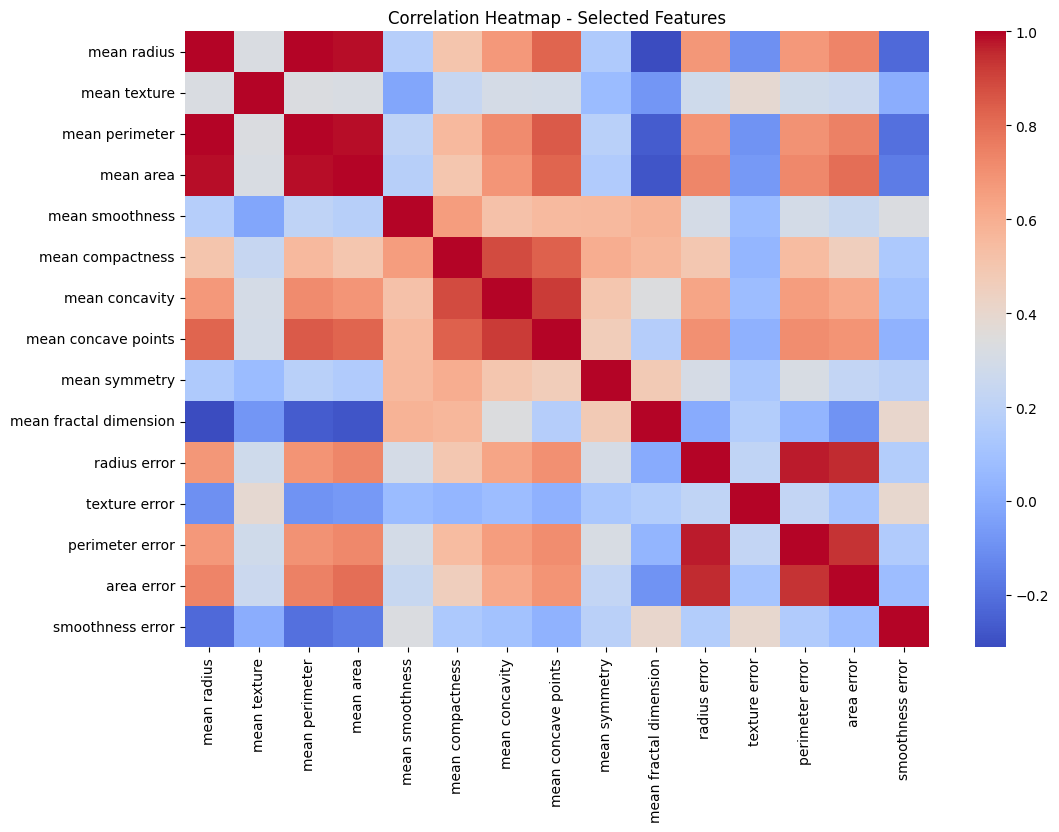

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.iloc[:, :15].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap - Selected Features")
plt.show()


## 8. Train-Test Split

An 80:20 split is used.

- Training samples: 455
- Test samples: 114

The test set remains untouched until final evaluation.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 455
Test samples: 114


## 9. Feature Scaling

StandardScaler is applied because Logistic Regression is sensitive
to feature scale.

The scaler is fitted only on the training data to prevent data leakage.


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Training data scaled successfully.
Scaled training shape: (455, 30)
Scaled test shape: (114, 30)


## 10. Preprocessing Summary

The preprocessing workflow consists of:

1. Dataset loading
2. Data quality checking
3. Missing-value analysis
4. Duplicate analysis
5. Descriptive statistics
6. Visualization
7. Train-test splitting
8. Feature scaling
9. Leakage prevention

This completes the preprocessing and feature engineering stage.
